# Probabilistic ensemble forecasting

Load an opinionated four-member Granite ensemble recipe, forecast hourly ETTh1 observations, and compare with held-out actuals. The recipe selects the checkpoints, quantiles, and aggregation settings; TTM's revision remains dynamically selected from context length and horizon.

## Install

For this development branch, install the checkout into the notebook environment. Restart the kernel if the package was already imported. After release, the installation can use the published granite-tsfm[notebooks] package.

In [5]:
from pathlib import Path

repo_root = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "pyproject.toml").is_file() and (p / "tsfm_public").is_dir()
)

%pip install -q -e "{repo_root}[notebooks]"

Note: you may need to restart the kernel to use updated packages.


In [6]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from tsfm_public.models.ensemble.configuration_ensemble import ProbabilisticEnsembleConfig
from tsfm_public.models.ensemble.modeling_ensemble import QuantileEnsembleTimeSeriesForecast
from tsfm_public.toolkit.time_series_preprocessor import prepare_data_splits

## Load the recipe

The local directory contains config.json. Once the recipe is published, replace this directory with its Hugging Face repository ID. Linear pooling is the default. To use the prescribed IQR-weighted alternative, uncomment the single assignment below before constructing the ensemble.

| aggregation_method | Behavior | Method-specific options |
|---|---|---|
| `"linear_pool"` (default) | Pools member quantile forecasts; equal influence by default | None |
| `"iqr_weighted"` | Gives greater weight to members with narrower interquantile ranges | `temperature`, `max_weight` in `config.iqr_weighted_options` |

IQR defaults are `temperature=0.5` and `max_weight=0.4`. Temperature must be finite and positive: lower values concentrate weights, while higher values move them toward uniform weighting. The cap must be between `1 / n_members` and `1`, or `None` to disable capping. If you reduce the member count, check that the cap remains valid. Narrower intervals do not necessarily indicate greater accuracy.

Advanced changes can be made to config.members or config.iqr_weighted_options and saved with config.save_pretrained("./my_ensemble_recipe"). Invalid recipes fail before checkpoints are loaded.

In [7]:
config = ProbabilisticEnsembleConfig.from_pretrained(
    repo_root / "notebooks/hfdemo/probabilistic_ensemble_recipe",
)
# config.aggregation_method = "iqr_weighted"

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
ensemble = QuantileEnsembleTimeSeriesForecast.from_config(config, device=device)

INFO:p-49369:t-8379490688:_client.py:_send_single_request:HTTP Request: HEAD https://huggingface.co/ibm-granite/granite-timeseries-patchtst-fm-r1/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:p-49369:t-8379490688:_client.py:_send_single_request:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/ibm-granite/granite-timeseries-patchtst-fm-r1/151f9c6d576281b95c2ff784d0863bd3f12c80f1/config.json?%2Fibm-granite%2Fgranite-timeseries-patchtst-fm-r1%2Fresolve%2Fmain%2Fconfig.json=&etag=%22c68bf3aae2f5f14421b7713c8a69b4f83c343d6f%22 "HTTP/1.1 200 OK"
INFO:p-49369:t-8379490688:_client.py:_send_single_request:HTTP Request: HEAD https://huggingface.co/ibm-granite/granite-timeseries-patchtst-fm-r1/resolve/main/model.safetensors "HTTP/1.1 302 Found"


Loading weights:   0%|          | 0/253 [00:00<?, ?it/s]

INFO:p-49369:t-8379490688:_client.py:_send_single_request:HTTP Request: HEAD https://huggingface.co/ibm-granite/granite-timeseries-patchtst-fm-r2/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:p-49369:t-8379490688:_client.py:_send_single_request:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/ibm-granite/granite-timeseries-patchtst-fm-r2/b125275f9204d37cbb81fe47b9cf5e08a521e829/config.json?%2Fibm-granite%2Fgranite-timeseries-patchtst-fm-r2%2Fresolve%2Fmain%2Fconfig.json=&etag=%22cb41afcd12aa16f82508d598f0be45cdcc727383%22 "HTTP/1.1 200 OK"
INFO:p-49369:t-8379490688:_client.py:_send_single_request:HTTP Request: HEAD https://huggingface.co/ibm-granite/granite-timeseries-patchtst-fm-r2/resolve/main/model.safetensors "HTTP/1.1 302 Found"
INFO:p-49369:t-8379490688:modeling_patchtst_fm.py:__init__:Stacked blocks: (0):ConformerBlock-5 --> (1):ConformerBlock-5 --> (2):ConformerBlock-3 --> (3):ConformerBlock-3 --> (4):ConformerBlock-5 --> (5):ConformerBlock-5

Loading weights:   0%|          | 0/646 [00:00<?, ?it/s]

INFO:p-49369:t-8379490688:_client.py:_send_single_request:HTTP Request: HEAD https://huggingface.co/ibm-granite/granite-timeseries-flowstate-r1/resolve/r1.1/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:p-49369:t-8379490688:_client.py:_send_single_request:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/ibm-granite/granite-timeseries-flowstate-r1/b80e0f1b1c2d90edebe3d4f243ad046a3f935daa/config.json?%2Fibm-granite%2Fgranite-timeseries-flowstate-r1%2Fresolve%2Fr1.1%2Fconfig.json=&etag=%226dc5733d8070b69bcc195d2fe4978faab3f439e0%22 "HTTP/1.1 200 OK"
INFO:p-49369:t-8379490688:_client.py:_send_single_request:HTTP Request: HEAD https://huggingface.co/ibm-granite/granite-timeseries-flowstate-r1/resolve/r1.1/model.safetensors "HTTP/1.1 302 Found"
INFO:p-49369:t-8379490688:modeling_flowstate.py:__init__: Total Number of parameters: 18524.928k
INFO:p-49369:t-8379490688:modeling_flowstate.py:__init__:Number of decoder parameters: 1181.952k (6.38%)


Loading weights:   0%|          | 0/118 [00:00<?, ?it/s]

In [8]:
config

ProbabilisticEnsembleConfig {
  "aggregation_method": "linear_pool",
  "iqr_weighted_options": {
    "max_weight": 0.4,
    "temperature": 0.5
  },
  "members": [
    {
      "forecaster_type": "patchtst",
      "model_checkpoint": "ibm-granite/granite-timeseries-patchtst-fm-r1"
    },
    {
      "forecaster_type": "patchtst",
      "model_checkpoint": "ibm-granite/granite-timeseries-patchtst-fm-r2"
    },
    {
      "forecaster_type": "flowstate",
      "model_checkpoint": "ibm-granite/granite-timeseries-flowstate-r1",
      "model_revision": "r1.1"
    },
    {
      "forecaster_type": "ttm",
      "model_checkpoint": "ibm-granite/granite-timeseries-ttm-r3"
    }
  ],
  "model_type": "granite_probabilistic_ensemble",
  "quantile_levels": [
    0.1,
    0.2,
    0.3,
    0.4,
    0.5,
    0.6,
    0.7,
    0.8,
    0.9
  ],
  "transformers_version": "5.17.0",
  "weights": null
}

## Prepare a held-out forecast window

Use the same ETTh1 split boundaries as the PatchTST getting-started notebook. Only the context is passed to the models; the next horizon is retained as ground truth. No training is needed. TTM uses the latest history supported by its selected checkpoint while preserving the common cutoff.

In [9]:
context_length = 4096
prediction_length = 96
target_column = "HUFL"

raw_df = pd.read_csv(
    "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv",
    parse_dates=["date"],
)
df = raw_df[["date", target_column]].rename(columns={"date": "timestamp", target_column: "target"})
_, _, test_df = prepare_data_splits(
    df,
    context_length=context_length,
    split_config={"train": [0, 8640], "valid": [8640, 11520], "test": [11520, 14400]},
)
forecast_input = test_df.iloc[:context_length].reset_index(drop=True)
forecast_actuals = test_df.iloc[context_length:context_length + prediction_length].reset_index(drop=True)

In [10]:
result = ensemble(
    forecast_input,
    timestamp_column="timestamp",
    target_columns=["target"],
    context_length=context_length,
    prediction_length=prediction_length,
)
# Retain the known actuals and cutoff for this notebook's single forecast window.
result.actuals = forecast_actuals["target"].to_numpy()[None, :, None].tolist()
result.cutoff_dates = [str(forecast_input["timestamp"].iloc[-1])]
print(result.message)

INFO:p-49369:t-8379490688:time_series_forecasting_pipeline.py:preprocess:Preprocessing with: {'prediction_length': 96, 'context_length': 4096, 'frequency_token': None, 'id_columns': [], 'timestamp_column': 'timestamp', 'target_columns': ['target'], 'impute_method': None, 'max_context_length': 8192}
INFO:p-49369:t-8379490688:time_series_forecasting_pipeline.py:preprocess:Preprocessing with: {'prediction_length': 96, 'context_length': 4096, 'frequency_token': None, 'id_columns': [], 'timestamp_column': 'timestamp', 'target_columns': ['target'], 'impute_method': None, 'max_context_length': 8192}
INFO:p-49369:t-8379490688:time_series_forecasting_pipeline.py:preprocess:Preprocessing with: {'prediction_length': 96, 'context_length': 4096, 'frequency_token': None, 'id_columns': [], 'timestamp_column': 'timestamp', 'target_columns': ['target'], 'impute_method': None, 'max_context_length': 4096}
INFO:p-49369:t-8379490688:get_model.py:get_model:Loading model from: ibm-granite/granite-timeseries-

Loading weights:   0%|          | 0/448 [00:00<?, ?it/s]

INFO:p-49369:t-8379490688:time_series_forecasting_pipeline.py:preprocess:Preprocessing with: {'prediction_length': 96, 'context_length': 2048, 'frequency_token': None, 'id_columns': [], 'timestamp_column': 'timestamp', 'target_columns': ['target'], 'observable_columns': [], 'control_columns': [], 'conditional_columns': [], 'categorical_columns': [], 'static_categorical_columns': [], 'impute_method': None, 'max_context_length': 2048}


Ensembling completed successfully.


/Users/fearghalodonncha/Work/DigitalTwin/TSFM_Agent/Development/tsfm_agent_repos/granite-tsfm-fork/granite-tsfm/tsfm_public/models/tinytimemixer/modeling_tinytimemixer.py:2377: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 1025, 1]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  fft = torch.fft.rfft(raw_input, dim=1)


## Plot the forecast

Show recent history, the ensemble median, its 10th–90th percentile interval, and held-out actuals. Narrower intervals do not necessarily indicate greater accuracy; evaluating methods requires multiple held-out windows.

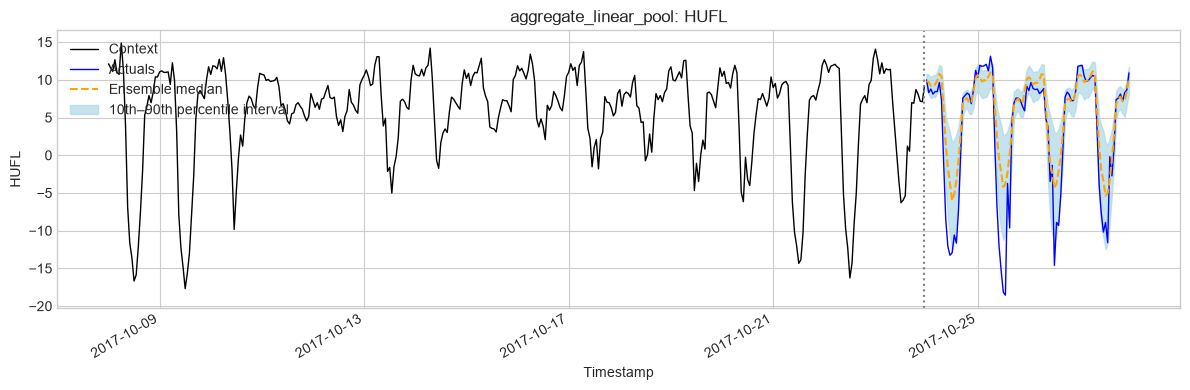

In [11]:
median = np.asarray(result.predicted)[0, :, 0]
quantiles = np.asarray(result.predicted_quantiles)[0, :, 0, :]
levels = ensemble.quantile_levels
timestamps = forecast_actuals["timestamp"]
history = forecast_input.tail(4 * prediction_length)

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(history["timestamp"], history["target"], label="Context", color="black", linewidth=1)
ax.plot(timestamps, forecast_actuals["target"], label="Actuals", color="blue", linewidth=1)
ax.plot(timestamps, median, label="Ensemble median", color="orange", linestyle="--")
ax.fill_between(
    timestamps,
    quantiles[:, levels.index(0.1)],
    quantiles[:, levels.index(0.9)],
    label="10th–90th percentile interval", color="lightblue", alpha=0.7,
)
ax.axvline(forecast_input["timestamp"].iloc[-1], color="gray", linestyle=":")
ax.set(title=f"{result.metadata['method']}: {target_column}", xlabel="Timestamp", ylabel=target_column)
ax.legend(loc="upper left")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()